In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# Load dataset
# Load the dataset from the provided path
file_path = '/Users/Augusto/Desktop/MentalDisorderClassification/Dataset-Mental-Disorders.csv'
df = pd.read_csv(file_path)

In [79]:
# Clean data
# Remove unnecessary spaces from column names and specific column values
df.columns = df.columns.str.strip()
df['Suicidal thoughts'] = df['Suicidal thoughts'].str.strip()

In [80]:
# Map categorical data
# Define mappings for categorical data to numeric values
frequency_mapping = {'Seldom': 0, 'Sometimes': 1, 'Usually': 2, 'Most-Often': 3}
rating_mapping = {f'{i} From 10': i for i in range(1, 11)}
yes_no_mapping = {'YES': 1, 'NO': 0}

In [81]:
# Specify which columns require specific mappings
frequency_cols = ['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder']
rating_cols = ['Sexual Activity', 'Concentration', 'Optimisim']
yes_no_cols = [
    'Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect',
    'Try-Explanation', 'Aggressive Response', 'Ignore & Move-On',
    'Nervous Break-down', 'Admit Mistakes', 'Overthinking'
]

In [82]:
# Apply frequency mapping to specified columns
for col in frequency_cols:
    df[col] = df[col].map(frequency_mapping).astype(int)

In [83]:
# Apply rating mapping to specified columns
for col in rating_cols:
    df[col] = df[col].map(rating_mapping).astype(int)

In [84]:
# Apply YES/NO mapping to binary columns
for col in yes_no_cols:
    df[col] = df[col].map(yes_no_mapping).astype(int)

In [85]:
# Map diagnosis column
# Map the diagnosis column to numerical values
diagnose_mapping = {'Normal': 0, 'Bipolar Type-1': 1, 'Bipolar Type-2': 2, 'Depression': 3}
df['Expert Diagnose'] = df['Expert Diagnose'].map(diagnose_mapping).astype(int)

In [86]:
# Remove unnecessary columns
# Drop the 'Patient Number' column if it exists
if 'Patient Number' in df.columns:
    df.drop('Patient Number', axis=1, inplace=True)

In [87]:
# Split data
# Separate features (X) and target variable (y)
X = df.drop('Expert Diagnose', axis=1)
y = df['Expert Diagnose']

In [88]:
# Model evaluation function
def evaluate_models(X, y):
    """
    Evaluate multiple classification models using cross-validation.
    """
    # Define models to evaluate
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'SVC': SVC(),
        'KNN': KNeighborsClassifier(n_neighbors=3),
        'Naive Bayes': GaussianNB(),
        'Perceptron': Perceptron(),
        'Linear SVC': SGDClassifier(),
        'Decision Tree': DecisionTreeClassifier(),
        'Random Forest': RandomForestClassifier(n_estimators=100),
    }

    # Lists to store results
    model_scores = []
    model_details = []

    # Iterate through models
    for name, model in models.items():
        # Use a pipeline to scale data and apply the model
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        # Perform cross-validation and calculate accuracy
        scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
        # Store the mean accuracy for the model
        model_scores.append({'Model': name, 'Mean Accuracy': round(np.mean(scores) * 100, 2)})
        # Store fold-wise accuracy details
        details = pd.DataFrame({
            'Fold': [f'Fold-{i+1}' for i in range(len(scores))],
            'Accuracy': scores
        })
        details['Model'] = name
        model_details.append(details)

# Combine results into DataFrames
    model_scores_df = pd.DataFrame(model_scores).sort_values(by='Mean Accuracy', ascending=False)
    return model_scores_df, pd.concat(model_details, ignore_index=True)

In [89]:
# Evaluate models
model_scores_df, model_details = evaluate_models(X, y)

In [90]:
# Display model comparison scores
print("\nModel Comparison with Scores:")
print(model_scores_df)


Model Comparison with Scores:
                 Model  Mean Accuracy
1                  SVC          89.17
0  Logistic Regression          88.33
4           Perceptron          88.33
7        Random Forest          87.50
5           Linear SVC          86.67
6        Decision Tree          78.33
2                  KNN          76.67
3          Naive Bayes          70.00


In [91]:
# Save detailed results and scores
model_scores_df.to_csv('model_scores.csv', index=False)
model_details.to_csv('model_details.csv', index=False)

C:\Users\Augusto\AppData\Local\Temp\ipykernel_27604\2748134001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_scores_df['Model'], y=model_scores_df['Mean Accuracy'], palette="pastel")


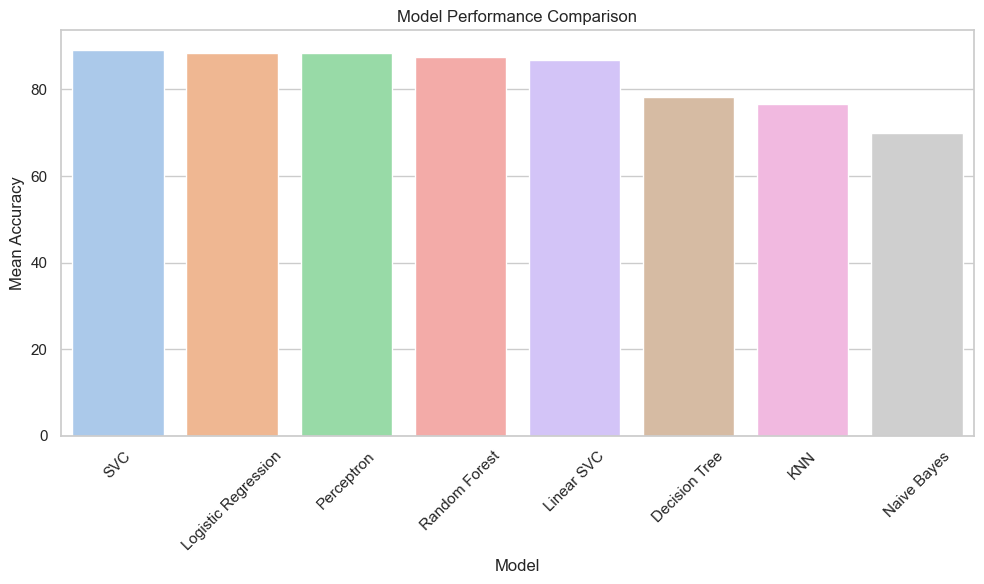

In [98]:
# Plot comparison
plt.figure(figsize=(10, 6))  # Configurar tamaño del gráfico
sns.barplot(x=model_scores_df['Model'], y=model_scores_df['Mean Accuracy'], palette="pastel")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
# Save and show plot
plt.savefig('model_comparison.png', dpi=300)
plt.show()

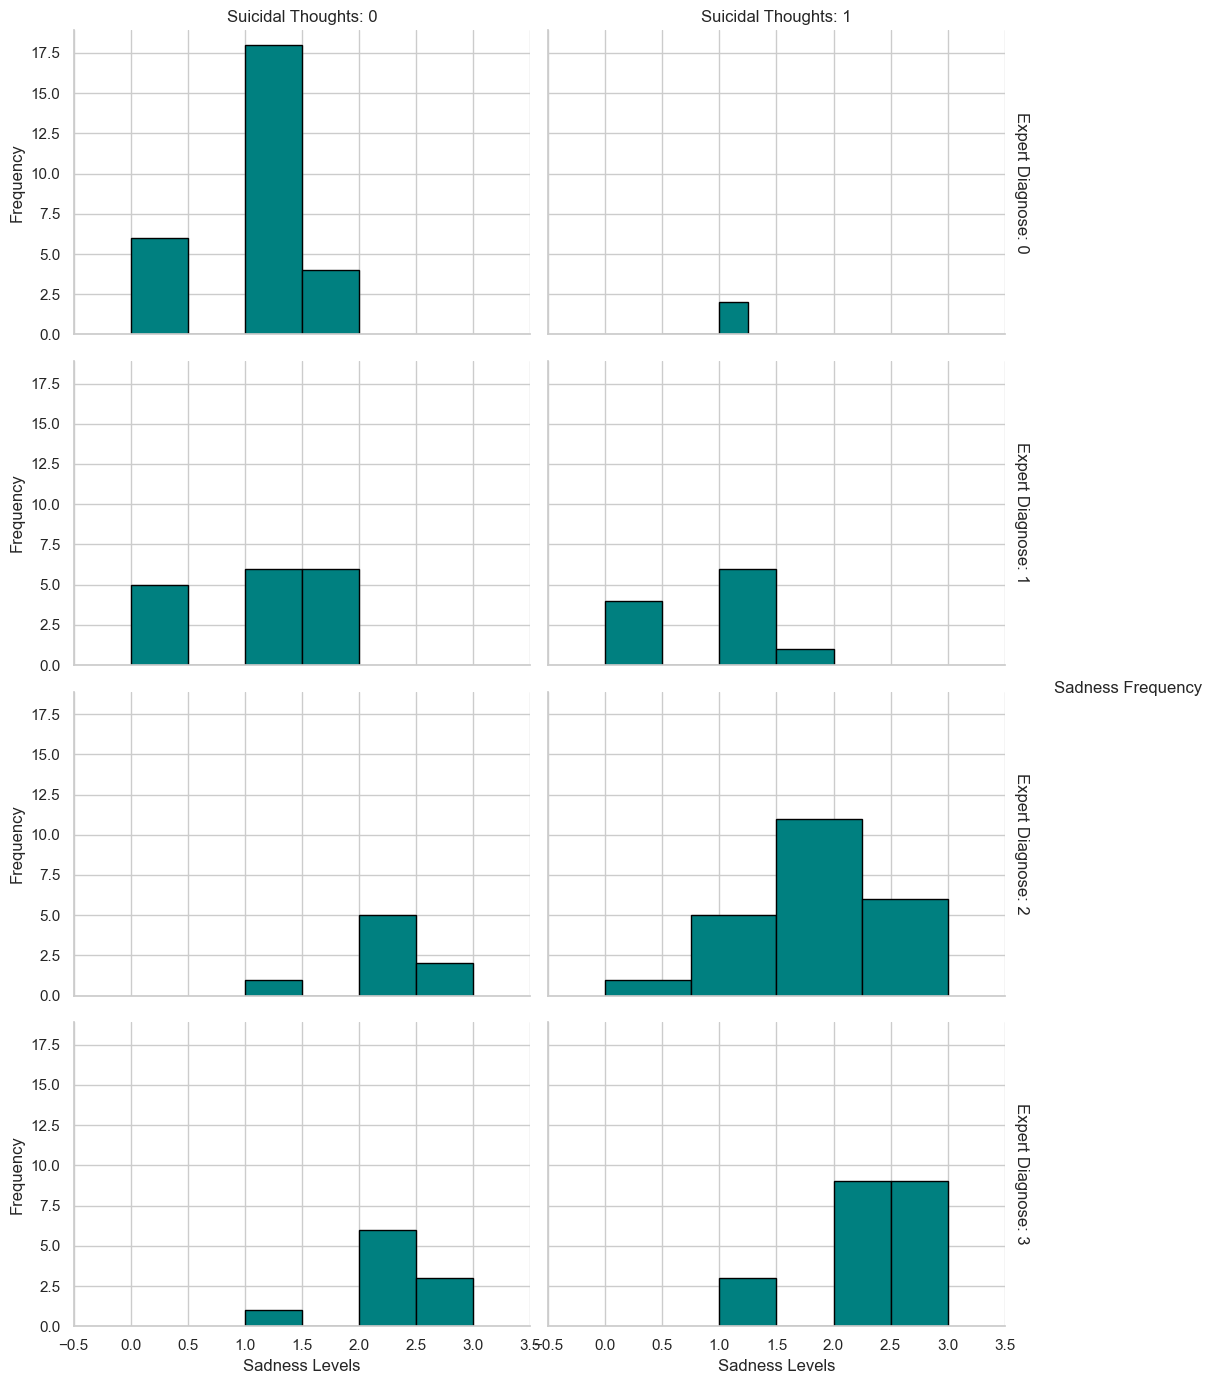

In [99]:
# Improved visualization for Sadness levels by diagnosis and suicidal thoughts
# Generate histograms for sadness levels split by suicidal thoughts and diagnosis
sns.set(style="whitegrid", palette="pastel")
grid = sns.FacetGrid(
    df,
    col="Suicidal thoughts",
    row="Expert Diagnose",
    height=3.5,
    aspect=1.5,
    margin_titles=True
)
grid.map(plt.hist, "Sadness", bins=4, edgecolor="black", color="teal")
grid.set_axis_labels("Sadness Levels", "Frequency")
grid.set_titles(col_template="Suicidal Thoughts: {col_name}", row_template="Expert Diagnose: {row_name}")
grid.set(xlim=(-0.5, 3.5))
grid.add_legend(title="Sadness Frequency")
# Save plot as an image
plt.savefig('sadness_levels_comparison.png', dpi=300)
plt.show()